# Stock Market News Impact Classifier

A machine learning and NLP-based project that classifies financial news into **LOW, MEDIUM, and HIGH impact categories**.

In [50]:
# Data manipulation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt   # Visualization
import seaborn as sns    # Visualization
import nltk # Text processing
import sklearn
import re   # Text processing

In [51]:
# Data load karo
df = pd.read_csv('stk.csv')

# Dekho kaisa dikhta hai
print(df.head())
print(df.shape)        # kitni rows, columns
print(df.info())       # data types
print(df['impact_tier'].value_counts()) 

         date                                              title  \
0  2016-01-01  Lending to foreign step-down arms of Indian fi...   
1  2016-01-02  IDBI Bank to raise Rs 900 cr through Basel-III...   
2  2016-01-02                          Forex reserves up $943 mn   
3  2016-01-02        SBI: Lending rate cut unlikely till end-Mar   
4  2016-01-03  ASK Group to invest Rs 1,500 cr in real estate...   

                                         description                url  \
0   RBI slaps 2% additional provision for such loans  URL_NOT_AVAILABLE   
1  Many banks have been raising money through tie...  URL_NOT_AVAILABLE   
2  India's foreign exchange reserves rose $943 mi...  URL_NOT_AVAILABLE   
3  Country's largest lender SBI today ruled out f...  URL_NOT_AVAILABLE   
4  ASK Group plans to step up its equity investme...  URL_NOT_AVAILABLE   

               source_file              categories matched_keywords  \
0  IndianFinancialNews.csv  sector_banking_finance              rbi  

In [53]:
# ==============================
# 3. DATA QUALITY & TARGET ANALYSIS
# ==============================

# Missing values
print("Missing Values:")
print(df.isnull().sum())

# Duplicate records
print("\nDuplicate Rows:", df.duplicated().sum())
print("Duplicate Headlines:", df["title"].duplicated().sum())

# Target class distribution
print("\nImpact Tier Distribution:")
print(df["impact_tier"].value_counts())

# Relevance score distribution
print("\nRelevance Score Distribution:")
print(df["relevance_score"].value_counts().sort_index())

# Check relationship between relevance_score and target
print("\nImpact Tier vs Relevance Score:")
display(
    pd.crosstab(
        df["impact_tier"],
        df["relevance_score"]
    )
)

Missing Values:
date                0
title               0
description         0
url                 0
source_file         0
categories          0
matched_keywords    0
relevance_score     0
has_negation        0
impact_tier         0
dtype: int64

Duplicate Rows: 0
Duplicate Headlines: 13

Impact Tier Distribution:
impact_tier
MEDIUM    79503
LOW       57368
HIGH       3048
Name: count, dtype: int64

Relevance Score Distribution:
relevance_score
1     10881
2     46487
3     63602
4      3742
5     12159
6      2089
7       587
8       312
9        41
10       16
11        3
Name: count, dtype: int64

Impact Tier vs Relevance Score:


relevance_score,1,2,3,4,5,6,7,8,9,10,11
impact_tier,,,,,,,,,,,
HIGH,0,0,0,0,0,2089,587,312,41,16,3
LOW,10881,46487,0,0,0,0,0,0,0,0,0
MEDIUM,0,0,63602,3742,12159,0,0,0,0,0,0


In [54]:
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

from scipy.sparse import csr_matrix, hstack

# ============================================================
# Load Dataset
# ============================================================



# ============================================================
# Stopwords
# ============================================================

stop_words = set(stopwords.words("english"))

# ============================================================
# Financial Feature Extraction
# ============================================================

# Percentage

def extract_percentage(text):
    match = re.search(r'(\d+(\.\d+)?)\s*%', str(text))
    if match:
        return float(match.group(1))
    return 0


# Money

def extract_money(text):
    match = re.search(r'₹\s?([\d,]+(\.\d+)?)', str(text))

    if match:
        return float(match.group(1).replace(',', ''))

    return 0


# Headline Length

def headline_length(text):
    return len(str(text))


# Word Count

def word_count(text):
    return len(str(text).split())


# ============================================================
# Create Financial Features
# ============================================================

df["percentage_value"] = df["title"].apply(extract_percentage)

df["money_value"] = df["title"].apply(extract_money)

df["headline_length"] = df["title"].apply(headline_length)

df["word_count"] = df["title"].apply(word_count)

# Existing Dataset Feature

df["has_negation"] = df["has_negation"].astype(int)

# ============================================================
# Text Cleaning
# ============================================================

def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Remove punctuation only
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Stopword Removal
    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)


df["clean_headline"] = df["title"].apply(clean_text)

# ============================================================
# Label Encoding
# ============================================================

label = LabelEncoder()

y = label.fit_transform(df["impact_tier"])

print(label.classes_)

# ============================================================
# TF-IDF
# ============================================================

vectorizer = TfidfVectorizer(
    max_features=5000
)

X_text = vectorizer.fit_transform(df["clean_headline"])

# ============================================================
# Numerical Features
# ============================================================

numeric_features = df[
    [
        "percentage_value",
        "money_value",
        "headline_length",
        "word_count",
        "has_negation"
    ]
]

# ============================================================
# Scaling
# ============================================================

scaler = MinMaxScaler()

numeric_scaled = scaler.fit_transform(numeric_features)

numeric_scaled = csr_matrix(numeric_scaled)

# ============================================================
# Final Feature Matrix
# ============================================================

X = hstack([
    X_text,
    numeric_scaled
])

print("Shape of X :", X.shape)
print("Shape of y :", y.shape)

['HIGH' 'LOW' 'MEDIUM']
Shape of X : (139919, 5005)
Shape of y : (139919,)


In [55]:
print(df.head())        # data kaisa dikhta hai
print(df.columns.tolist())  # exact column names
print(df.shape)         # kitni rows columns

         date                                              title  \
0  2016-01-01  Lending to foreign step-down arms of Indian fi...   
1  2016-01-02  IDBI Bank to raise Rs 900 cr through Basel-III...   
2  2016-01-02                          Forex reserves up $943 mn   
3  2016-01-02        SBI: Lending rate cut unlikely till end-Mar   
4  2016-01-03  ASK Group to invest Rs 1,500 cr in real estate...   

                                         description                url  \
0   RBI slaps 2% additional provision for such loans  URL_NOT_AVAILABLE   
1  Many banks have been raising money through tie...  URL_NOT_AVAILABLE   
2  India's foreign exchange reserves rose $943 mi...  URL_NOT_AVAILABLE   
3  Country's largest lender SBI today ruled out f...  URL_NOT_AVAILABLE   
4  ASK Group plans to step up its equity investme...  URL_NOT_AVAILABLE   

               source_file              categories matched_keywords  \
0  IndianFinancialNews.csv  sector_banking_finance              rbi  

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       # 20% testing ke liye
    random_state=42,      # reproducible results
    stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 111935
Testing samples: 27984


In [57]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
}

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


--- Naive Bayes ---
Accuracy: 0.8666
[[    0    45   564]
 [    0  9545  1929]
 [    0  1196 14705]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       609
           1       0.88      0.83      0.86     11474
           2       0.86      0.92      0.89     15901

    accuracy                           0.87     27984
   macro avg       0.58      0.59      0.58     27984
weighted avg       0.85      0.87      0.86     27984



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



--- Logistic Regression ---
Accuracy: 0.8800
[[  437    28   144]
 [   70 11193   211]
 [ 1637  1268 12996]]
              precision    recall  f1-score   support

           0       0.20      0.72      0.32       609
           1       0.90      0.98      0.93     11474
           2       0.97      0.82      0.89     15901

    accuracy                           0.88     27984
   macro avg       0.69      0.84      0.71     27984
weighted avg       0.93      0.88      0.89     27984


--- Random Forest ---
Accuracy: 0.9371
[[   69    25   515]
 [    1 11216   257]
 [    5   958 14938]]
              precision    recall  f1-score   support

           0       0.92      0.11      0.20       609
           1       0.92      0.98      0.95     11474
           2       0.95      0.94      0.95     15901

    accuracy                           0.94     27984
   macro avg       0.93      0.68      0.70     27984
weighted avg       0.94      0.94      0.93     27984



In [58]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")

Naive Bayes: 0.8525 ± 0.0217
Logistic Regression: 0.8707 ± 0.0136
Random Forest: 0.9302 ± 0.0102


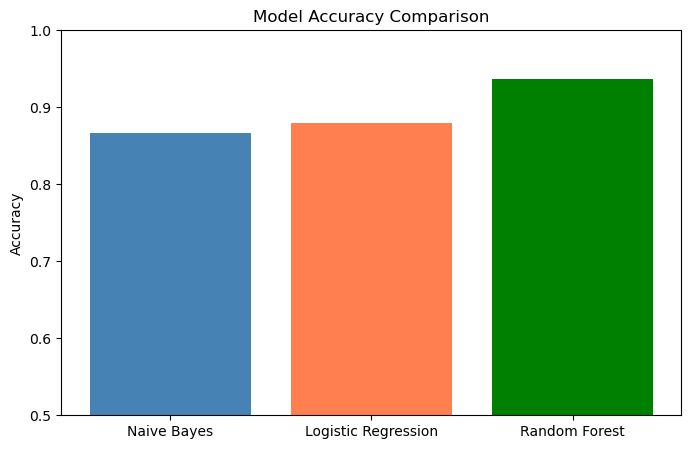

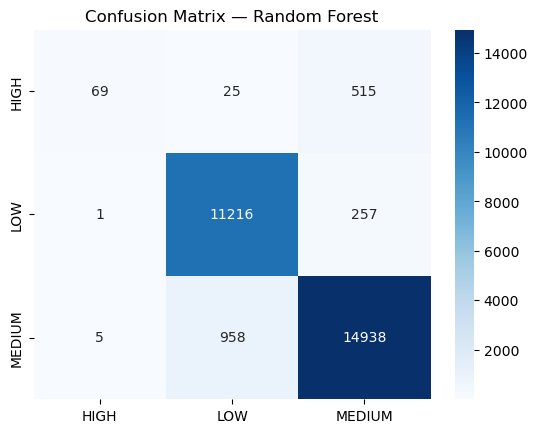

In [44]:
import seaborn as sns

# Model comparison
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['steelblue', 'coral', 'green'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)
plt.show()

# Confusion Matrix best model ke liye
best_model = models['Random Forest']
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            
            xticklabels=label.classes_,
            yticklabels=label.classes_)
plt.title('Confusion Matrix — Random Forest')
plt.show()

In [59]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from collections import Counter
import pandas as pd

# # Step 1 — Train test split (y is already label-encoded: HIGH=0, LOW=1, MEDIUM=2)
# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     stratify=y,
#     random_state=42
# )

# Step 2 — SMOTE apply karo
sm = SMOTE(random_state=42, k_neighbors=5)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

print("Before SMOTE")
print(Counter(y_train))
print("\nAfter SMOTE")
print(Counter(y_resampled))

# # Step 3 — Model train karo
# model = RandomForestClassifier(
#     n_estimators=100,
#     random_state=42,
#     n_jobs=-1
# )
# model.fit(X_resampled, y_resampled)

# Step 4 — Evaluate karo
y_pred = model.predict(X_test)
print(classification_report(
    y_test, y_pred,
    labels=[0, 1, 2],
    target_names=['HIGH', 'LOW', 'MEDIUM']
))

Before SMOTE
Counter({np.int64(2): 63602, np.int64(1): 45894, np.int64(0): 2439})

After SMOTE
Counter({np.int64(1): 63602, np.int64(2): 63602, np.int64(0): 63602})
              precision    recall  f1-score   support

        HIGH       0.92      0.11      0.20       609
         LOW       0.92      0.98      0.95     11474
      MEDIUM       0.95      0.94      0.95     15901

    accuracy                           0.94     27984
   macro avg       0.93      0.68      0.70     27984
weighted avg       0.94      0.94      0.93     27984



In [73]:
# ==============================
# APPLY SMOTE TO TRAINING DATA
# ==============================

from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(
    random_state=42,
    k_neighbors=5
)

X_resampled, y_resampled = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(Counter(y_train))

print("\nAfter SMOTE:")
print(Counter(y_resampled))

Before SMOTE:
Counter({np.int64(2): 63602, np.int64(1): 45894, np.int64(0): 2439})

After SMOTE:
Counter({np.int64(1): 63602, np.int64(2): 63602, np.int64(0): 63602})


In [77]:


# # ==============================
# # TRAIN FINAL RANDOM FOREST MODEL
# # ==============================

# model = RandomForestClassifier(
#     n_estimators=100,
#     random_state=42,
#     n_jobs=-1,
#     class_weight="balanced_subsample"
# )

# model.fit(
#     X_resampled,
#     y_resampled
# )

# print("Final Random Forest model trained successfully.")

# ==========================================
# FINAL RANDOM FOREST MODEL
# ==========================================

from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

final_model.fit(X_resampled, y_resampled)

print("Final Random Forest model trained successfully.")
print("Classes:", final_model.classes_)

Final Random Forest model trained successfully.
Classes: [0 1 2]


In [63]:
probs = model.predict_proba(X_test)
print(model.classes_)   # order check karo, e.g. [0 1 2] = [HIGH LOW MEDIUM]

import numpy as np
# Agar P(HIGH) > 0.3 hai, toh HIGH bol do — chahe woh argmax na ho
y_pred_custom = np.where(probs[:, 0] > 0.3, 0, np.argmax(probs[:, 1:], axis=1) + 1)

print(classification_report(y_test, y_pred_custom,
      labels=[0,1,2], target_names=['HIGH','LOW','MEDIUM']))

[0 1 2]
              precision    recall  f1-score   support

        HIGH       0.74      0.55      0.63       609
         LOW       0.92      0.98      0.95     11474
      MEDIUM       0.97      0.93      0.95     15901

    accuracy                           0.94     27984
   macro avg       0.87      0.82      0.84     27984
weighted avg       0.94      0.94      0.94     27984



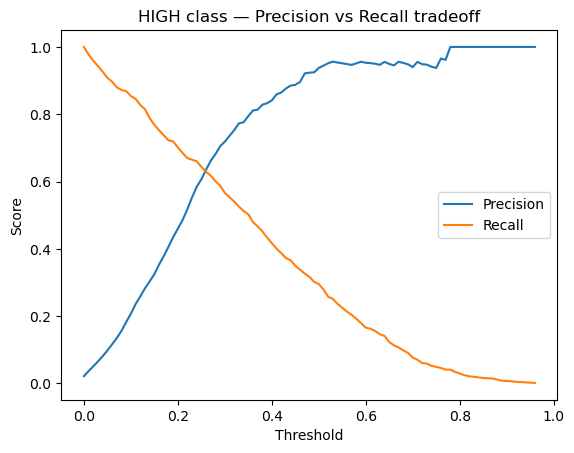

In [64]:
import matplotlib.pyplot as plt

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('HIGH class — Precision vs Recall tradeoff')
plt.legend()
plt.show()

In [65]:
BEST_THRESHOLD = 0.29

y_pred_final = np.where(probs[:, 0] > BEST_THRESHOLD, 0, np.argmax(probs[:, 1:], axis=1) + 1)

print(classification_report(y_test, y_pred_final,
      labels=[0,1,2], target_names=['HIGH','LOW','MEDIUM']))

              precision    recall  f1-score   support

        HIGH       0.72      0.57      0.63       609
         LOW       0.92      0.98      0.95     11474
      MEDIUM       0.97      0.93      0.95     15901

    accuracy                           0.94     27984
   macro avg       0.87      0.83      0.84     27984
weighted avg       0.94      0.94      0.94     27984



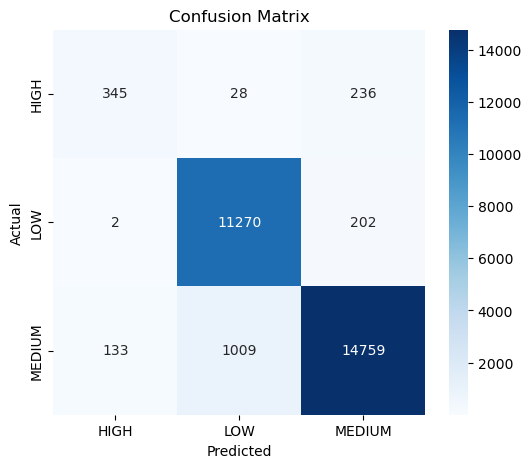

In [67]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_final, labels=[0,1,2])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['HIGH','LOW','MEDIUM'],
            yticklabels=['HIGH','LOW','MEDIUM'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [70]:
!pip install newsapi-python

from newsapi import NewsApiClient

newsapi = NewsApiClient(api_key='72f5b901f6ab451fa404148a838fa9ac')

# India ki business news lao
articles = newsapi.get_everything(
    q='RBI OR Sensex OR Nifty OR stock market',
    language='en',
    sort_by='publishedAt',
    page_size=10
)

for article in articles['articles']:
    print(article['title'])
    print(article['publishedAt'])
    print('---')

Defaulting to user installation because normal site-packages is not writeable
MLB rumors: Phillies could go bigger than expected; how Aaron Judge's injury may affect Yankees' plans
2026-07-23T14:33:36Z
---
Betty Crocker Reveals New Line Of Harry Potter Treats
2026-07-23T14:33:09Z
---
New Oracle AI database targets cost, data residency concerns
2026-07-23T14:33:00Z
---
BTGO Investors Have Opportunity to Lead BitGo Holdings, Inc. Securities Fraud Lawsuit with the Schall Law Firm
2026-07-23T14:33:00Z
---
The electric vehicle market is out of gas — you can guess who's freaking out | Blaze Media
2026-07-23T14:32:17Z
---
A history of oil price swings this century
2026-07-23T14:32:12Z
---
New Brezza faces volume test as Maruti Suzuki seeks to win back SUV buyers
2026-07-23T14:32:10Z
---
Rhyu Si-min, Once Lee Jae-myung’s Champion, Turns on the President He Helped Elect
2026-07-23T14:32:00Z
---
Nasdaq tops profit estimates on high-profile listings and data revenue
2026-07-23T14:31:51Z
---


In [78]:
import time

def fetch_and_predict():
    articles = newsapi.get_everything(
        q='stock market India',
        language='en',
        sort_by='publishedAt',
        page_size=5
    )
    
    for article in articles['articles']:
        headline = article['title']
        predict_news(headline)  # tumhara pehle ka function

# Har baar manually chalao
fetch_and_predict()

# Ya automatic loop banao (careful — yeh notebook block kar dega)
# while True:
#     fetch_and_predict()
#     time.sleep(1800)  # 30 minute wait

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Headline: Richardson Electronics Q4 Earnings Call Highlights
Prediction: LOW
Probabilities → HIGH: 0.00, LOW: 0.89, MEDIUM: 0.11

Headline: NBA Champion John Salley and United Wealth Education Join Forces
Prediction: LOW
Probabilities → HIGH: 0.00, LOW: 0.91, MEDIUM: 0.09

Headline: Ahead of Market: 10 things that will decide stock market action on Friday
Prediction: MEDIUM
Probabilities → HIGH: 0.00, LOW: 0.09, MEDIUM: 0.91

Headline: Q1 Results Today Highlights: Infosys, Airtel Africa, PVR INOX post strong numbers; IndiGo, Cipla and Meesho deliver mixed results
Prediction: HIGH
Probabilities → HIGH: 0.58, LOW: 0.10, MEDIUM: 0.32

Headline: Eight Roads, Flipkart, IMM offer Shadowfax shares worth ₹1,048 crore as lock-in ends
Prediction: LOW
Probabilities → HIGH: 0.00, LOW: 0.64, MEDIUM: 0.36



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [79]:
# NewsAPI se kuch fresh headlines lao
articles = newsapi.get_everything(q='stock market', page_size=5)

# Manually predict karke dikhao ki pipeline kaam karta hai
for article in articles['articles']:
    predict_news(article['title'])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Headline: The Best Fake Christmas Trees on the Market Are 50% Off for Prime Day (2026)
Prediction: LOW
Probabilities → HIGH: 0.01, LOW: 0.50, MEDIUM: 0.49

Headline: Polestar has been muscled out of the US market
Prediction: MEDIUM
Probabilities → HIGH: 0.01, LOW: 0.49, MEDIUM: 0.50

Headline: SpaceX in your index fund, explained
Prediction: LOW
Probabilities → HIGH: 0.00, LOW: 0.85, MEDIUM: 0.15

Headline: AOL’s Parent Company Just IPO’d. No, It’s Not 1992
Prediction: MEDIUM
Probabilities → HIGH: 0.00, LOW: 0.00, MEDIUM: 1.00



In [66]:
def predict_news(headline, threshold=0.29):
    # Same cleaning jo training mein use ki thi
    clean = clean_text(headline)
    
    # Same features nikaalo jo training mein banaye the
    pct = extract_percentage(headline)
    money = extract_money(headline)
    h_len = headline_length(headline)
    w_count = word_count(headline)
    negation = 0   # agar tumhare paas negation detect karne ka function hai toh use karo
    
    # TF-IDF transform (fit_transform NAHI — sirf transform, kyunki vectorizer already fit hai)
    X_text_new = vectorizer.transform([clean])
    
    # Numeric features same order mein jaise training mein the
    import numpy as np
    numeric_new = np.array([[pct, money, h_len, w_count, negation]])
    numeric_scaled_new = scaler.transform(numeric_new)
    
    from scipy.sparse import csr_matrix, hstack
    X_new = hstack([X_text_new, csr_matrix(numeric_scaled_new)])
    
    # Predict with tuned threshold
    probs = model.predict_proba(X_new)
    pred = 0 if probs[0][0] > threshold else np.argmax(probs[0][1:]) + 1
    
    labels = ['HIGH', 'LOW', 'MEDIUM']
    print(f"Headline: {headline}")
    print(f"Prediction: {labels[pred]}")
    print(f"Probabilities — HIGH: {probs[0][0]:.2f}, LOW: {probs[0][1]:.2f}, MEDIUM: {probs[0][2]:.2f}")
    print()

# Test karo
predict_news("RBI cuts repo rate by 50 basis points, markets surge")
predict_news("Company announces routine board meeting")
predict_news("Reliance shares crash 15% after fraud allegations")

Headline: RBI cuts repo rate by 50 basis points, markets surge
Prediction: MEDIUM
Probabilities — HIGH: 0.01, LOW: 0.34, MEDIUM: 0.65

Headline: Company announces routine board meeting
Prediction: LOW
Probabilities — HIGH: 0.00, LOW: 0.74, MEDIUM: 0.26

Headline: Reliance shares crash 15% after fraud allegations
Prediction: LOW
Probabilities — HIGH: 0.00, LOW: 0.81, MEDIUM: 0.19



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [69]:
# ==============================
# PREDICT NEW FINANCIAL NEWS
# ==============================

def detect_negation(text):
    """Detect common negation words in a headline."""
    
    negation_pattern = r"\b(no|not|never|neither|nor|without|unlikely)\b"
    
    return int(
        bool(
            re.search(
                negation_pattern,
                str(text).lower()
            )
        )
    )


def predict_news(headline, threshold=BEST_THRESHOLD):

    # 1. Same text cleaning used during training
    clean = clean_text(headline)

    # 2. Extract the same numerical features used during training
    pct = extract_percentage(headline)
    money = extract_money(headline)
    h_len = headline_length(headline)
    w_count = word_count(headline)
    negation = detect_negation(headline)

    # 3. Transform text using already-fitted TF-IDF vectorizer
    X_text_new = vectorizer.transform([clean])

    # 4. Numerical features in the exact same training order
    numeric_new = np.array([
        [
            pct,
            money,
            h_len,
            w_count,
            negation
        ]
    ])

    # Use already-fitted scaler
    numeric_scaled_new = scaler.transform(numeric_new)
    numeric_scaled_new = csr_matrix(numeric_scaled_new)

    # 5. Combine text + numerical features
    X_new = hstack([
        X_text_new,
        numeric_scaled_new
    ])

    # 6. Predict probabilities
    probs = final_model.predict_proba(X_new)[0]

    # HIGH class = 0
    if probs[0] > threshold:
        pred = 0
    else:
        pred = np.argmax(probs[1:]) + 1

    labels = ["HIGH", "LOW", "MEDIUM"]

    print(f"Headline: {headline}")
    print(f"Prediction: {labels[pred]}")
    print(
        f"Probabilities → "
        f"HIGH: {probs[0]:.2f}, "
        f"LOW: {probs[1]:.2f}, "
        f"MEDIUM: {probs[2]:.2f}"
    )
    print()

    return labels[pred]